In [180]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [181]:
df = pd.read_json(r'D:\IMP  ML  PROJECTS\CAR PRICE PREDICTION\web scraping\extraction\car_dataset_ahmedabad.json')

In [182]:
req_cols = []
with open (r'features.txt', 'r') as f:
    features = f.read().split('\n')
for i in features:
    if i in df.columns:
        req_cols.append(i)
df = df[req_cols]
df.to_csv('dataset.csv')

In [183]:
df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,Engine,No. of Cylinders,Valves Per Cylinder,Valve Configuration,Fuel Supply System,Fuel Type,Engine Type,Emission Norm Compliance,Kerb Weight,Drive Type,Transmission,Power
0,0,1197 cc,4.0,4.0,DOHC,MPFI,Petrol,Kappa VTVT Petrol Engine,BS IV,935 kg,FWD,Manual,82 bhp
1,1,1086 cc,4.0,3.0,SOHC,MPFI,Petrol,IRDE2 Engine,BS IV,860 kg,FWD,Manual,68.05 bhp
2,2,1196 cc,4.0,4.0,DOHC,SEFI,Petrol,Petrol Engine,BS IV,1090 kg,Front Wheel Drive,Manual,70 bhp
3,3,1197 cc,4.0,4.0,DOHC,MPFI,Petrol,Kappa VTVT Petrol Engine,NaN,1060 kg,FWD,Manual,81.86 bhp
4,4,936 cc,3.0,4.0,DOHC,Direct Injection,Diesel,SMARTECH Diesel Engine,BS IV,1025 kg,FWD,Manual,56.3 bhp


In [184]:
df.columns

Index(['Unnamed: 0', 'Engine', 'No. of Cylinders', 'Valves Per Cylinder',
       'Valve Configuration', 'Fuel Supply System', 'Fuel Type', 'Engine Type',
       'Emission Norm Compliance', 'Kerb Weight', 'Drive Type', 'Transmission',
       'Power'],
      dtype='object')

In [185]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [186]:
# Print percentage missing in each feature
for col in df.columns:
    print(f'{col}: {df[col].isnull().sum() / len(df) * 100}')
    

Engine: 1.303538175046555
No. of Cylinders: 0.8379888268156425
Valves Per Cylinder: 0.8379888268156425
Valve Configuration: 31.00558659217877
Fuel Supply System: 27.37430167597765
Fuel Type: 0.186219739292365
Engine Type: 3.072625698324022
Emission Norm Compliance: 13.966480446927374
Kerb Weight: 7.82122905027933
Drive Type: 13.594040968342643
Transmission: 0.186219739292365
Power: 2.8864059590316575


In [187]:
def one_hot_encode_with_info(df, column_name, prefix=None):
    
    if prefix is None:
        prefix = column_name

    # get categories
    categories = sorted(df[column_name].dropna().unique())

    print(f"\nFeature: {column_name}")
    print("All Categories:", categories)

    dropped_category = categories[0]
    print("Dropped Category:", dropped_category)

    # create dummies
    dummies = pd.get_dummies(
        df[column_name],
        prefix=prefix,
        drop_first=True
    )

    # add to dataframe
    df = pd.concat([df, dummies], axis=1)

    # drop original column
    df.drop(columns=[column_name], inplace=True)

    return df, dropped_category

1. Engine

In [188]:
df["Engine"] = (
    df["Engine"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)    
)

df["Engine"] = pd.to_numeric(df["Engine"], errors="coerce")
df['Engine'].fillna(df['Engine'].median(), inplace=True)

2. No. of Cylinders

In [189]:
df['No. of Cylinders'].fillna(df['No. of Cylinders'].mode()[0], inplace=True)

3. Valves Per Cylinder

In [190]:
df['Valves Per Cylinder'].fillna(df['Valves Per Cylinder'].mode()[0], inplace=True)

4. Fuel Supply System

In [191]:
df['Fuel Supply System'].fillna(df['Fuel Supply System'].mode()[0], inplace=True)

In [192]:
def clean_fuel_supply(x):
    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "mpfi" in x or "multi point" in x or "mpi" in x:
        return "MPFI"

    elif "crdi" in x or "common rail" in x or "tdci" in x or "ddis" in x or "cdi" in x:
        return "CRDI"

    elif "gdi" in x or "direct injection" in x:
        return "GDI"

    elif "efi" in x or "electronic fuel injection" in x or "electronic injection" in x:
        return "EFI"

    else:
        return "Other"


df["Fuel Supply System"] = df["Fuel Supply System"].apply(clean_fuel_supply)

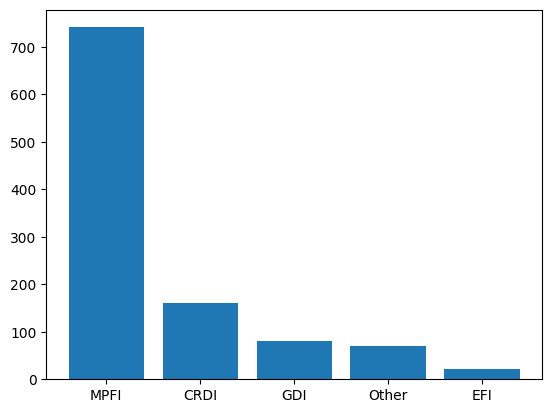

In [193]:
plt.bar(df['Fuel Supply System'].value_counts().index, df['Fuel Supply System'].value_counts().values)
plt.show()

In [194]:
df, dropped_fuel_sys = one_hot_encode_with_info(df, "Fuel Supply System", "FuelSys")


Feature: Fuel Supply System
All Categories: ['CRDI', 'EFI', 'GDI', 'MPFI', 'Other']
Dropped Category: CRDI


5. Fuel Type

In [195]:
df['Fuel Type'].fillna(df['Fuel Type'].mode()[0], inplace=True)
df['Fuel Type'].value_counts()

Fuel Type
Petrol      809
Diesel      231
CNG          28
Electric      6
Name: count, dtype: int64

In [196]:
# Drop all the row with 'Fuel Type' == 'Electric'
df = df[df['Fuel Type'] != 'Electric']

df, dropped_fuel_type = one_hot_encode_with_info(df, "Fuel Type", "Fuel")


Feature: Fuel Type
All Categories: ['CNG', 'Diesel', 'Petrol']
Dropped Category: CNG


6. 'Engine Type'

In [197]:
df['Engine Type'].fillna(df['Engine Type'].mode()[0], inplace=True)

df['Engine Type'].value_counts()

Engine Type
Kappa VTVT Petrol Engine     139
i-VTEC Petrol Engine          46
In-Line Engine                45
Petrol Engine                 44
IRDE2 Engine                  37
                            ... 
1.2L U2 CRDi Diesel            1
2.0 TSI                        1
Kryotec 2.0L                   1
In-Line Diesel Engine          1
DOHC Dual VVT-i Petrol En      1
Name: count, Length: 215, dtype: int64

In [198]:
def extract_engine_type(x):

    if pd.isna(x):
        return None

    x = str(x).lower()

    if "vtec" in x:
        return "VTEC"

    elif "vvt" in x:
        return "VVT"

    elif "tsi" in x:
        return "TSI"

    elif "tdi" in x:
        return "TDI"

    elif "crdi" in x:
        return "CRDI"

    elif "dohc" in x:
        return "DOHC"

    elif "sohc" in x:
        return "SOHC"

    elif "inline" in x or "in-line" in x:
        return "INLINE"

    else:
        return "Other"


df["Engine Type"] = df["Engine Type"].apply(extract_engine_type)

df['Engine Type'].value_counts()

Engine Type
Other     765
VTEC      108
VVT        63
INLINE     48
CRDI       45
TSI        29
TDI         4
DOHC        3
SOHC        3
Name: count, dtype: int64

In [199]:
df, dropped_engine_type = one_hot_encode_with_info(
    df,
    "Engine Type",
    "EngineType"
)


Feature: Engine Type
All Categories: ['CRDI', 'DOHC', 'INLINE', 'Other', 'SOHC', 'TDI', 'TSI', 'VTEC', 'VVT']
Dropped Category: CRDI


7. 'Emission Norm Compliance'

In [200]:
df['Emission Norm Compliance'].fillna(df['Emission Norm Compliance'].mode()[0], inplace=True)
df['Emission Norm Compliance'].value_counts()

Emission Norm Compliance
BS IV               578
BS VI               279
BS VI 2.0           147
Bharat Stage IV      26
BSIV                 21
Bharat Stage III     11
BS III                3
Euro VI               1
Euro IV               1
Euro V                1
Name: count, dtype: int64

In [201]:
def clean_emission_norm(x):

    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "bs vi" in x or "bsvi" in x:
        return "BS6"

    elif "bs iv" in x or "bsiv" in x or "bharat stage iv" in x:
        return "BS4"

    elif "bs iii" in x or "bharat stage iii" in x:
        return "BS3"

    elif "euro" in x:
        return "EURO"

    else:
        return "Other"


df["Emission Norm Compliance"] = df["Emission Norm Compliance"].apply(clean_emission_norm)

In [202]:
df, dropped_emission_norm = one_hot_encode_with_info(df, "Emission Norm Compliance", "EmissionNorm")


Feature: Emission Norm Compliance
All Categories: ['BS3', 'BS4', 'BS6', 'EURO']
Dropped Category: BS3


8. 'Kerb Weight'

In [203]:
df['Kerb Weight'] = df['Kerb Weight'].str.extract(r'(\d+)').astype(float)

df['Kerb Weight'].fillna(df['Kerb Weight'].median(), inplace=True)

9. 'Drive Type'

In [204]:
def clean_drive_type(value):
    value = str(value).strip().upper().replace(' ', '')
    
    if value in ['FWD', '2WD', '4X2', '2WD', 'FRONTWHEELDRIVE', 'TWOWHEELDRIVE', 'TWOWHHEELDRIVE']:
        return 'FWD'
    elif value in ['RWD', 'RWD(WITHMTT)']:
        return 'RWD'
    elif value in ['AWD', '4WD', '4X4']:
        return 'AWD'
    else:
        return value

df['Drive Type'] = df['Drive Type'].apply(clean_drive_type)

df['Drive Type'].fillna(df['Drive Type'].mode()[0], inplace=True)

In [205]:
df, droped_drive_type = one_hot_encode_with_info(df, "Drive Type", "DriveType")


Feature: Drive Type
All Categories: ['AWD', 'FWD', 'NAN', 'RWD', 'TWOWHHELDRIVE']
Dropped Category: AWD


10. 'Transmission'

In [206]:
transmission_map = {
    "Automatic": 1,
    "Manual": 0 
}

df['Transmission'] = df['Transmission'].map(transmission_map)

df['Transmission'].fillna(df['Transmission'].mode()[0], inplace=True)

11. Power

In [207]:
df['Power'].head()

0       82 bhp
1    68.05 bhp
2       70 bhp
3    81.86 bhp
4     56.3 bhp
Name: Power, dtype: object

In [208]:
df['Power'] = df['Power'].str.replace(' bhp', '', regex=False).astype(float)

df['Power'].fillna(df['Power'].median(), inplace=True)

11. 'Valve Configuration'

In [209]:
df['Valve Configuration'].fillna(df['Valve Configuration'].mode()[0], inplace=True)

In [210]:
df, dropped_valve_config = one_hot_encode_with_info(df, "Valve Configuration", "ValveConfig")


Feature: Valve Configuration
All Categories: ['DOHC', 'DOHC with TIS', 'DOHC with VIS', 'SOHC', 'iDSI']
Dropped Category: DOHC


'engine_density'

In [211]:
df['Engine Density'] = df['Engine'] / df['No. of Cylinders']

df['Engine Density'].head()

0    299.25
1    271.50
2    299.00
3    299.25
4    312.00
Name: Engine Density, dtype: float64

In [212]:
df.columns

Index(['Engine', 'No. of Cylinders', 'Valves Per Cylinder', 'Kerb Weight',
       'Transmission', 'Power', 'FuelSys_EFI', 'FuelSys_GDI', 'FuelSys_MPFI',
       'FuelSys_Other', 'Fuel_Diesel', 'Fuel_Petrol', 'EngineType_DOHC',
       'EngineType_INLINE', 'EngineType_Other', 'EngineType_SOHC',
       'EngineType_TDI', 'EngineType_TSI', 'EngineType_VTEC', 'EngineType_VVT',
       'EmissionNorm_BS4', 'EmissionNorm_BS6', 'EmissionNorm_EURO',
       'DriveType_FWD', 'DriveType_NAN', 'DriveType_RWD',
       'DriveType_TWOWHHELDRIVE', 'ValveConfig_DOHC with TIS',
       'ValveConfig_DOHC with VIS', 'ValveConfig_SOHC', 'ValveConfig_iDSI',
       'Engine Density'],
      dtype='object')

---

In [213]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import r2_score, mean_absolute_error

In [214]:
bool_features = df.select_dtypes(include='bool').columns.tolist()

def bool_to_int_converter(df):
    return df.astype(int)

preprocessor = ColumnTransformer(
    transformers=[
        ('bool_to_int', FunctionTransformer(bool_to_int_converter), bool_features)
    ],
    remainder='passthrough'  # Keeps all other features in the dataset
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])

In [215]:
param_grid = {
    'regressor__n_estimators': [100, 500],
    'regressor__max_depth': [3, 6, 10],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

In [216]:
X = df.drop(columns=['Power'], axis=1)
y = df['Power']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [218]:
grid_search.fit(X_train, y_train)

# Output results
print(f"Best Score: {grid_search.best_score_}")
print(f"Best Params: {grid_search.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Best Score: -65.54542259522802
Best Params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 500, 'regressor__subsample': 0.8}


In [219]:
# 1. Extract the best model from the grid search
best_model = grid_search.best_estimator_

# 2. Make predictions on the test set
y_pred = best_model.predict(X_test)

# 3. Quick evaluation
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):,.2f}")

R2 Score: 0.9449
Mean Absolute Error: 3.14
